# Лабораторна робота. Комп'ютерний практикум 2

## Задача 2, варіант 2.

**Рівняння Ріккаті** має загальний вигляд:
$$y' = P(x)\,y^2 + Q(x)\,y + R(x)$$

Якщо відомий частковий розв'язок $y = \varphi(x)$, то заміна
$$y = z + \varphi(x)$$
зводить рівняння Річчаті до **рівняння Бернуллі** відносно $z(x)$:
$$z' = \bigl[2P(x)\varphi(x) + Q(x)\bigr]z + P(x)\,z^2.$$

---

## Задача

Розв'язати рівняння Річчаті:
$$y' = -\frac{y^2}{x^4} + \frac{4y}{x} + 1$$

In [1]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt

x = symbols('x')
y = Function('y')
z = Function('z')
C1 = symbols('C1')

# Вихідне рівняння Річчаті
ode = Eq(y(x).diff(x), -y(x)**2/x**4 + 4*y(x)/x + 1)
print('Вихідне рівняння Річчаті:')
display(ode)

P_func = Rational(-1,1)/x**4
Q_func = Integer(4)/x
R_func = Integer(1)
print(f'P(x) = {P_func},  Q(x) = {Q_func},  R(x) = {R_func}')

Вихідне рівняння Річчаті:


Eq(Derivative(y(x), x), 1 + 4*y(x)/x - y(x)**2/x**4)

P(x) = -1/x**4,  Q(x) = 4/x,  R(x) = 1


## Крок 1. Знаходження часткового розв'язку

Шукаємо частковий розв'язок у вигляді $y_0 = x^2(x + c)$ (поліном).

Підставимо $y_0 = x^2(x + 1)$ і перевіримо.

In [2]:
# Частковий розв'язок y0 = x^2*(x+1)
phi = x**2 * (x + 1)
print('Кандидат y₀ =', phi, '=', expand(phi))

lhs_phi = diff(phi, x)
rhs_phi = -phi**2/x**4 + 4*phi/x + 1
residual = simplify(lhs_phi - rhs_phi)

print('y₀\' =', expand(lhs_phi))
print('Py₀² + Qy₀ + R =', expand(rhs_phi))
print('Невязка =', residual)

if residual == 0:
    print('ok: y₀ = x^2(x+1) є частковим розв\'язком!')

Кандидат y₀ = x**2*(x + 1) = x**3 + x**2
y₀' = 3*x**2 + 2*x
Py₀² + Qy₀ + R = 3*x**2 + 2*x
Невязка = 0
ok: y₀ = x^2(x+1) є частковим розв'язком!


## Крок 2. Зведення до рівняння Бернуллі 

Заміна $y = z + \varphi(x) = z + x^2(x+1)$.

Підставляємо в рівняння та спрощуємо, враховуючи що $\varphi' = P\varphi^2 + Q\varphi + R$:

$$z' = \underbrace{\left[\frac{2(-1)}{x^4}\cdot x^2(x+1) + \frac{4}{x}\right]}_{a(x)}\,z + \underbrace{\left(-\frac{1}{x^4}\right)}_{b(x)}\,z^2$$

In [3]:
# Коефіцієнти рівняння Бернуллі
a_coef = simplify(2*P_func*phi + Q_func)
b_coef = P_func
print('a(x) = 2P(x)phi(x) + Q(x) =', a_coef)
print('b(x) = P(x) =', b_coef)

bern_ode = Eq(z(x).diff(x), a_coef*z(x) + b_coef*z(x)**2)
print('\nРівняння Бернуллі (n=2):')
display(bern_ode)

a(x) = 2P(x)phi(x) + Q(x) = 2*(x - 1)/x**2
b(x) = P(x) = -1/x**4

Рівняння Бернуллі (n=2):


Eq(Derivative(z(x), x), 2*(x - 1)*z(x)/x**2 - z(x)**2/x**4)

## Крок 3. Розв'язання рівняння Бернуллі

Рівняння Бернуллі з $n = 2$ розв'язується заміною $w = z^{1-2} = \dfrac{1}{z}$.

Тоді $z' = -w'/w^2$, і рівняння стає **лінійним першого порядку**:
$$w' + a(x)\,w = -b(x) = \frac{1}{x^4}$$

In [4]:
# Розв'язання Бернуллі
z_sol = dsolve(bern_ode, z(x))
print('Загальний розв\'язок z(x):')
display(z_sol)

# Лінійне рівняння для w = 1/z
w = Function('w')
linear_ode = Eq(w(x).diff(x) + a_coef*w(x), -b_coef)
print('\nЛінійне рівняння для w = 1/z:')
display(linear_ode)
w_sol = dsolve(linear_ode, w(x))
print('w(x) =')
display(w_sol)

Загальний розв'язок z(x):


Eq(z(x), 2*x**2*exp(2/x)/(C1 - exp(2/x)))


Лінійне рівняння для w = 1/z:


Eq(Derivative(w(x), x) + 2*(x - 1)*w(x)/x**2, x**(-4))

w(x) =


Eq(w(x), (C1*exp(-2/x) - 1/2)/x**2)

## Крок 4. Загальний розв'язок

Повертаємось до вихідної змінної:
$$y(x) = z(x) + \varphi(x) = z(x) + x^2(x+1)$$

In [5]:
# Загальний розв'язок
y_general = simplify(z_sol.rhs + phi)

print('=' * 60)
print('ЗАГАЛЬНИЙ РОЗВ\'ЯЗОК:')
print('=' * 60)
display(Eq(y(x), y_general))

# Явна форма
y_explicit = x**2*(C1*x*exp(2/x) - C1*exp(2/x) - x - 1)/(C1*exp(2/x) - 1)
print('\nАбо явно:')
display(Eq(y(x), y_explicit))

print('\nОсобливий розв\'язок (C1 -> 0):')
display(Eq(y(x), phi))

ЗАГАЛЬНИЙ РОЗВ'ЯЗОК:


Eq(y(x), x**2*((C1 - exp(2/x))*(x + 1) + 2*exp(2/x))/(C1 - exp(2/x)))


Або явно:


Eq(y(x), x**2*(C1*x*exp(2/x) - C1*exp(2/x) - x - 1)/(C1*exp(2/x) - 1))


Особливий розв'язок (C1 -> 0):


Eq(y(x), x**2*(x + 1))

## Крок 5. Перевірка

In [6]:
# Перевірка підстановкою
print('ПЕРЕВІРКА загального розв\'язку')
y_ch = x**2*(C1*x*exp(2/x) - C1*exp(2/x) - x - 1)/(C1*exp(2/x) - 1)
res = simplify(diff(y_ch, x) - (-y_ch**2/x**4 + 4*y_ch/x + 1))
print('Невязка y\' - (Py² + Qy + R) =', res)
print('ok!' if res == 0 else 'wrong!')

print('\nПЕРЕВІРКА Особливого розв\'язку y₀ = x²(x+1)')
res0 = simplify(diff(phi, x) - (-phi**2/x**4 + 4*phi/x + 1))
print('Невязка =', res0)
print('ok!' if res0 == 0 else 'wrong!')

ПЕРЕВІРКА загального розв'язку
Невязка y' - (Py² + Qy + R) = 0
ok!

ПЕРЕВІРКА Особливого розв'язку y₀ = x²(x+1)
Невязка = 0
ok!


## Крок 6. Графічна візуалізація

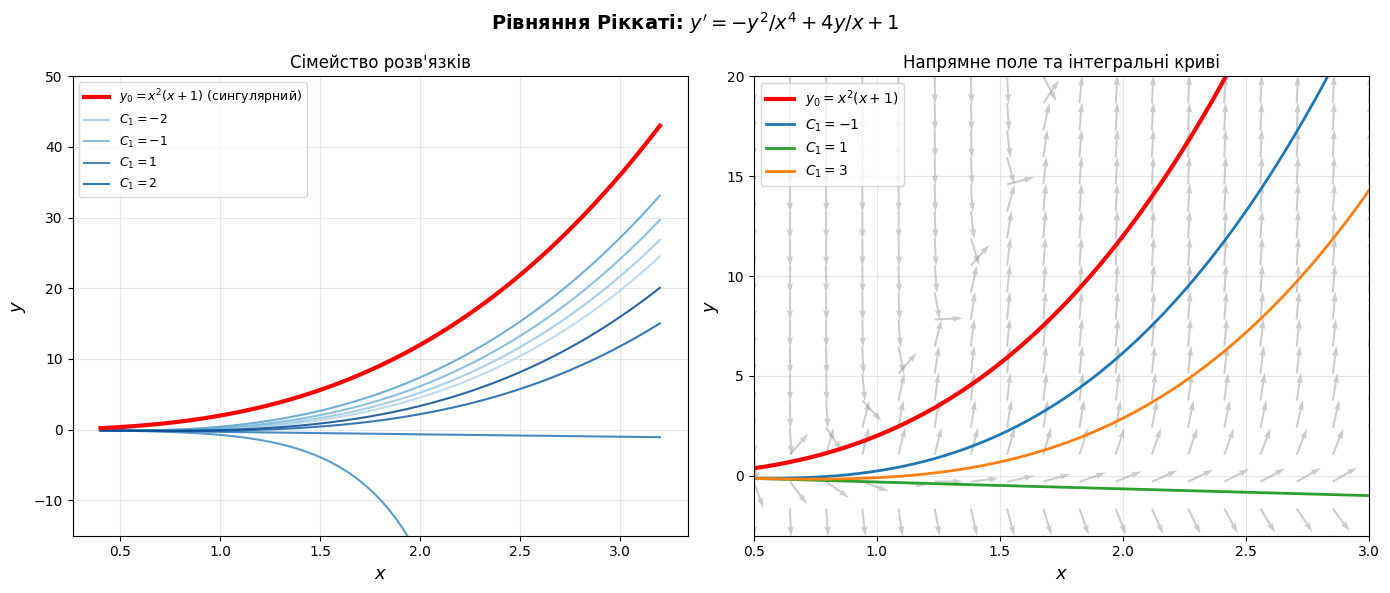

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
x_v = np.linspace(0.4, 3.2, 600)

# --- Ліва панель: сімейство розв'язків ---
ax1 = axes[0]
y0_v = x_v**2 * (x_v + 1)
ax1.plot(x_v, y0_v, 'r-', lw=3, zorder=5, label=r'$y_0=x^2(x+1)$ (сингулярний)')

c_vals = [-5, -2, -1, -0.5, 0.5, 1, 2, 5]
cmap = plt.cm.Blues(np.linspace(0.3, 0.9, len(c_vals)))
for i, c in enumerate(c_vals):
    with np.errstate(all='ignore'):
        e = np.exp(2.0/x_v)
        y_v_arr = x_v**2*(c*x_v*e - c*e - x_v - 1)/(c*e - 1)
    y_v_arr = np.where(np.abs(y_v_arr) > 60, np.nan, y_v_arr)
    lbl = f'$C_1={c}$' if abs(c) in [1, 2] else None
    ax1.plot(x_v, y_v_arr, '-', color=cmap[i], lw=1.5, alpha=0.85, label=lbl)

ax1.set_ylim(-15, 50)
ax1.set_xlabel('$x$', fontsize=13); ax1.set_ylabel('$y$', fontsize=13)
ax1.set_title("Сімейство розв'язків", fontsize=12)
ax1.legend(fontsize=9, loc='upper left'); ax1.grid(True, alpha=0.3)

# --- Права панель: напрямне поле ---
ax2 = axes[1]
Xg, Yg = np.meshgrid(np.linspace(0.5, 3.0, 18), np.linspace(-3, 20, 18))
with np.errstate(all='ignore'):
    DY = -Yg**2/Xg**4 + 4*Yg/Xg + 1
    norm = np.sqrt(1 + DY**2)
    DY /= norm
ax2.quiver(Xg, Yg, 1/norm, DY, alpha=0.4, color='gray', scale=22)
ax2.plot(x_v, y0_v, 'r-', lw=3, label=r'$y_0 = x^2(x+1)$')
for c, col in zip([-1, 1, 3], ['#1f77b4', '#2ca02c', '#ff7f0e']):
    with np.errstate(all='ignore'):
        e = np.exp(2.0/x_v)
        yc = x_v**2*(c*x_v*e - c*e - x_v - 1)/(c*e - 1)
    yc = np.where((np.abs(yc) > 25) | ~np.isfinite(yc), np.nan, yc)
    ax2.plot(x_v, yc, '-', color=col, lw=2, label=f'$C_1={c}$')
ax2.set_xlim(0.5, 3.0); ax2.set_ylim(-3, 20)
ax2.set_xlabel('$x$', fontsize=13); ax2.set_ylabel('$y$', fontsize=13)
ax2.set_title('Напрямне поле та інтегральні криві', fontsize=12)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

plt.suptitle(r"Рівняння Ріккаті: $y' = -y^2/x^4 + 4y/x + 1$", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Poshtak_lab_2_2.png', dpi=130, bbox_inches='tight')
plt.show()

## Підсумок

| Крок | Дія | Результат |
|:----:|-----|----------|
| 1 | Ідентифікуємо коефіцієнти | $P=-1/x^4$, $Q=4/x$, $R=1$ |
| 2 | Знаходимо $y_0$ (Випадок 3) | $y_0 = x^2(x+1)$ |
| 3 | Заміна $y = z + y_0$ | Рівняння Бернуллі $(n=2)$ |
| 4 | Заміна $w = 1/z$ | Лінійне рівняння 1-го порядку |
| 5 | Розв'язуємо лінійне рівняння | $z(x)$, потім $y = z + y_0$ |

### Відповідь:

$$\boxed{y(x) = \frac{x^2\bigl(C_1 x\,e^{2/x} - C_1 e^{2/x} - x - 1\bigr)}{C_1\,e^{2/x} - 1}}$$

Сингулярний розв'язок: $y_0 = x^2(x+1)$ (при $C_1 \to 0$).